### Objective

* Load the windowed data and reuse the patient-level train/validation/test split from Notebook 07.
* Train an iTransformer from scratch as the Tier 1 baseline.
* Optimise the model using a masked loss based on observed target values.
* Evaluate performance using MAE, RMSE, and MASE on the held-out test set.
* Compare forecasting performance across physiological variables and against a persistence baseline.
* Repeat the experiment on the fixed-anchor windows for comparison with the rolling-window setup. As the rolling and fixed-window datasets represent different physiological stages of mechanical ventilation, the comparison is intended to assess forecasting behaviour rather than isolate the effect of window count.
* Save the trained model, results tables, and figures for later cross-tier evaluation.







### Imports and configuration

**Initial BigQuery setup by Ayushi Kashyap - adapted for this notebook.**

In [1]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt
import json

In [2]:
PROJECT_ID         = 'capstoneweaningprediction' #@param {type:"string"}
DATASET_PROJECT_ID = 'amsterdamumcdb'            #@param {type:"string"}
DATASET_ID         = 'version1_5_0'              #@param {type:"string"}
LOCATION           = 'eu'                        #@param {type:"string"}

In [3]:
import os
from google.colab import auth
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
auth.authenticate_user()
print('Authenticated')

Authenticated


In [4]:
%load_ext google.colab.data_table
from google.colab.data_table import DataTable
DataTable.max_columns = 50
DataTable.max_rows    = 80000

In [5]:
%load_ext bigquery_magics
from bigquery_magics import bigquery_magics
def_config = bigquery.job.QueryJobConfig(
    default_dataset=DATASET_PROJECT_ID + '.' + DATASET_ID
)
bigquery_magics.context.default_query_job_config = def_config
client = bigquery.Client(
    project=PROJECT_ID, location=LOCATION,
    default_query_job_config=def_config
)
print('BigQuery client ready')

BigQuery client ready


### 01. Setup and configuration

In [6]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Data paths
DATA_DIR = Path("/content/sample_data")
GRID_PATH = DATA_DIR / "windows_tier12_grid.npz"
METADATA_PATH = DATA_DIR / "windows_metadata.json"

# Training settings
CONTEXT_HOURS = 48
HORIZONS = [1, 4, 8]
N_HORIZONS = len(HORIZONS)

D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.1

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
N_EPOCHS = 50
EARLY_STOP_PATIENCE = 8

print("Configuration loaded")
print(f"Context: {CONTEXT_HOURS} hours")
print(f"Horizons: {HORIZONS}")

Device: cpu
Configuration loaded
Context: 48 hours
Horizons: [1, 4, 8]


### 02. Loading the Windowed Data and Reconstructing Splits

In [7]:
# Load the metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Metadata:", list(metadata.keys()))

# Load the arrays
grid_data = np.load(GRID_PATH, allow_pickle=True)
print("Arrays:", list(grid_data.keys()))

context = grid_data["X_context"]
context_mask = grid_data["X_context_mask"]
targets = grid_data["y_target"]
target_mask = grid_data["y_target_mask"]

window_ids = grid_data["window_ids"]
visit_ids = grid_data["visit_ids"]

print(f"Context shape: {context.shape}")
print(f"Target shape: {targets.shape}")
print(f"Windows: {len(window_ids)}")
print(f"Patients: {len(np.unique(visit_ids))}")

split_labels = grid_data["split"]

# Split masks
train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("\nData split:")

for name, mask in [
    ("Train", train_mask),
    ("Val", val_mask),
    ("Test", test_mask),
]:
    n_windows = int(mask.sum())
    n_patients = len(np.unique(visit_ids[mask]))
    windows_per_patient = n_windows / n_patients

    print(
        f"{name:6s}: "
        f"{n_patients:5d} patients | "
        f"{n_windows:5d} windows | "
        f"{windows_per_patient:.1f} windows/patient"
    )

# Check the window split
assert (
    train_mask.astype(int)
    + val_mask.astype(int)
    + test_mask.astype(int)
    == 1
).all(), "Invalid window split."

# Check the patient split
train_patients = set(visit_ids[train_mask])
val_patients = set(visit_ids[val_mask])
test_patients = set(visit_ids[test_mask])

assert len(train_patients & val_patients) == 0, "Train/Val overlap."
assert len(train_patients & test_patients) == 0, "Train/Test overlap."
assert len(val_patients & test_patients) == 0, "Val/Test overlap."

print("\nSplit checks passed.")

Metadata: ['context_hours', 't_range_hours', 't_stride_hours', 'horizons', 'valid_origins', 'grid_start', 'grid_end', 'features', 'n_windows', 'n_visits', 'split_fractions', 'split_counts', 'units_note', 'scaler_stats', 'random_state']
Arrays: ['X_context', 'X_context_mask', 'y_target', 'y_target_mask', 'window_ids', 'visit_ids', 'split']
Context shape: (8202, 48, 13)
Target shape: (8202, 3, 13)
Windows: 8202
Patients: 1715

Data split:
Train :  1200 patients |  5729 windows | 4.8 windows/patient
Val   :   257 patients |  1240 windows | 4.8 windows/patient
Test  :   258 patients |  1233 windows | 4.8 windows/patient

Split checks passed.


**Interpretation**

The dataset was split at the patient level, so all windows from the same patient stay together. There are 1,200 training patients, 257 validation patients, and 258 test patients, giving 5,729, 1,240, and 1,233 windows. The checks confirmed that no patient appears in more than one dataset, preventing data leakage.

#### 03. Building the dataset and DataLoaders

In [8]:
class VentilatorWindowDataset(Dataset):
    def __init__(self, context, context_mask, targets, target_mask):
        self.context = torch.tensor(context, dtype=torch.float32)
        self.context_mask = torch.tensor(context_mask, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.target_mask = torch.tensor(target_mask, dtype=torch.float32)

    def __len__(self):
        return self.context.shape[0]

    def __getitem__(self, idx):
        return (
            self.context[idx],
            self.context_mask[idx],
            self.targets[idx],
            self.target_mask[idx],
        )

# Create datasets
train_dataset = VentilatorWindowDataset(
    context[train_mask], context_mask[train_mask],
    targets[train_mask], target_mask[train_mask],
)

val_dataset = VentilatorWindowDataset(
    context[val_mask], context_mask[val_mask],
    targets[val_mask], target_mask[val_mask],
)

test_dataset = VentilatorWindowDataset(
    context[test_mask], context_mask[test_mask],
    targets[test_mask], target_mask[test_mask],
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Check one batch
x, x_mask, y, y_mask = next(iter(train_loader))

print(f"Context batch shape: {x.shape}")
print(f"Target batch shape:  {y.shape}")

Train batches: 180
Val batches:   39
Test batches:  39
Context batch shape: torch.Size([32, 48, 13])
Target batch shape:  torch.Size([32, 3, 13])


**Interpretation**

The data is grouped into batches of 32. Each batch gives the model 48 hours of 13 variables and asks for 3 future time points, which matches what the model expects.

#### 04. Defining the iTransformer Model

In [9]:
class ITransformer(nn.Module):
    def __init__(self, n_variates, context_len, n_horizons,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()

        self.n_variates = n_variates
        self.context_len = context_len
        self.n_horizons = n_horizons

        # Embed each variable
        self.variate_embedding = nn.Linear(context_len, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # Forecast layer
        self.forecast_head = nn.Linear(d_model, n_horizons)

    def forward(self, context):
        # (batch, context_len, variables) -> (batch, variables, context_len)
        x = context.permute(0, 2, 1)

        # Variable embeddings
        x = self.variate_embedding(x)

        # Attention across variables
        x = self.encoder(x)

        # Predict each horizon
        out = self.forecast_head(x)

        # (batch, variables, horizons) -> (batch, horizons, variables)
        out = out.permute(0, 2, 1)

        return out


N_VARIATES = context.shape[2]

model = ITransformer(
    n_variates=N_VARIATES,
    context_len=CONTEXT_HOURS,
    n_horizons=N_HORIZONS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

n_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params:,}")

# Check the output shape
with torch.no_grad():
    output = model(x.to(device))

print(f"Output shape: {output.shape}")

Trainable parameters: 103,299
Output shape: torch.Size([32, 3, 13])


**Interpretation**

The model has about 103,000 trainable parameters, which is small and suitable for a dataset of this size. The test output shape is correct, so the model turns 48 hours of input into 3 future predictions.

*AI assistance: Used Claude Opus 4.8 to help with the permutation logic that treats each variable as a token instead of each time step.*

#### 05. Defining the masked Loss Function

I am defining custom loss functions to calculate loss on real observations not on the imputed values.

In [10]:
def masked_mae_loss(predictions, targets, mask):
    # All inputs have shape (batch, horizons, variables)

    abs_error = torch.abs(predictions - targets)
    masked_error = abs_error * mask

    # Average over observed values only
    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


def masked_mse_loss(predictions, targets, mask):
    # Mean squared error using observed values only

    sq_error = (predictions - targets) ** 2
    masked_error = sq_error * mask

    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


# Check the loss on one batch
with torch.no_grad():
    pred = model(x.to(device))
    loss = masked_mae_loss(
        pred,
        y.to(device),
        y_mask.to(device),
    )

print(f"Sample MAE loss: {loss.item():.4f}")

Sample MAE loss: 0.9516


**Interpretation**

The untrained model gives a loss of about 0.95. It is a normal finite number, so the masking works and only genuinely observed values are being counted.

#### 06. Training Loop

In [11]:
import time
import copy

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    # Run one epoch
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_observed = 0.0

    for context_b, context_mask_b, targets_b, target_mask_b in loader:
        context_b = context_b.to(device)
        targets_b = targets_b.to(device)
        target_mask_b = target_mask_b.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            predictions = model(context_b)
            loss = masked_mae_loss(predictions, targets_b, target_mask_b)

        if training:
            loss.backward()
            optimizer.step()

        n_observed = target_mask_b.sum().item()
        total_loss += loss.item() * n_observed
        total_observed += n_observed

    return total_loss / (total_observed + 1e-8)


# Train the model
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = " <-- best"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:3d} | "
        f"Train MAE: {train_loss:.4f} | "
        f"Val MAE: {val_loss:.4f}{marker}"
    )

    # Stop if validation loss does not improve
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch} "
            f"(no improvement for {EARLY_STOP_PATIENCE} epochs)."
        )
        break

elapsed = time.time() - start_time

# Load the best model
model.load_state_dict(best_model_state)

print(f"\nTraining finished in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"Best validation MAE: {best_val_loss:.4f}")

Epoch   1 | Train MAE: 0.6131 | Val MAE: 0.5428 <-- best
Epoch   2 | Train MAE: 0.5445 | Val MAE: 0.5177 <-- best
Epoch   3 | Train MAE: 0.5268 | Val MAE: 0.5077 <-- best
Epoch   4 | Train MAE: 0.5186 | Val MAE: 0.5044 <-- best
Epoch   5 | Train MAE: 0.5145 | Val MAE: 0.5003 <-- best
Epoch   6 | Train MAE: 0.5109 | Val MAE: 0.4993 <-- best
Epoch   7 | Train MAE: 0.5085 | Val MAE: 0.4966 <-- best
Epoch   8 | Train MAE: 0.5072 | Val MAE: 0.4952 <-- best
Epoch   9 | Train MAE: 0.5054 | Val MAE: 0.4959
Epoch  10 | Train MAE: 0.5040 | Val MAE: 0.4958
Epoch  11 | Train MAE: 0.5034 | Val MAE: 0.4939 <-- best
Epoch  12 | Train MAE: 0.5024 | Val MAE: 0.4939
Epoch  13 | Train MAE: 0.5017 | Val MAE: 0.4935 <-- best
Epoch  14 | Train MAE: 0.5003 | Val MAE: 0.4955
Epoch  15 | Train MAE: 0.4996 | Val MAE: 0.4924 <-- best
Epoch  16 | Train MAE: 0.4986 | Val MAE: 0.4924
Epoch  17 | Train MAE: 0.4985 | Val MAE: 0.4918 <-- best
Epoch  18 | Train MAE: 0.4977 | Val MAE: 0.4923
Epoch  19 | Train MAE: 0.496

**Interpretation**

Training and validation error fall together and then flatten, which means the model learns without overfitting. Training finished in under a minute and the best epoch was saved.

*AI assistance: Used Claude Opus 4.8 to help with the early-stopping logic and weighting each batch by its number of observed cells.*

#### Persistance Baseline and MASE

In [12]:
# --- Guard checks: fail loudly if a genuine prerequisite is missing ---
assert "model" in dir(), "model not found — run the training cell first."

# Extract scaler stats and feature names from metadata
feat = metadata["features"]
if isinstance(feat[0], dict):
    feature_names = [f.get("name") or f.get("feature") for f in feat]
else:
    feature_names = list(feat)

scaler_mean = np.array([metadata['scaler_stats'][f]['mean'] for f in feature_names])
scaler_std = np.array([metadata['scaler_stats'][f]['std'] for f in feature_names])

assert len(feature_names) == len(scaler_mean) == N_VARIATES, \
    "feature_names / scaler_mean / N_VARIATES length mismatch — check ordering."
print("Feature order (confirm this matches array columns):")
print(feature_names)
print()

# --- One pass over test set: collect preds, targets, masks, AND context+context_mask ---
model.eval()
p_list, t_list, tm_list, c_list, cm_list = [], [], [], [], []
with torch.no_grad():
    for context_b, context_mask_b, targets_b, target_mask_b in test_loader:
        preds = model(context_b.to(device)).cpu().numpy()
        p_list.append(preds)
        t_list.append(targets_b.numpy())
        tm_list.append(target_mask_b.numpy())
        c_list.append(context_b.numpy())
        cm_list.append(context_mask_b.numpy())

all_preds   = np.concatenate(p_list,  axis=0)   # (N,3,13) scaled
all_targets = np.concatenate(t_list,  axis=0)   # (N,3,13) scaled
all_masks   = np.concatenate(tm_list, axis=0)   # (N,3,13)
all_context = np.concatenate(c_list,  axis=0)   # (N,48,13) scaled
all_ctx_mask= np.concatenate(cm_list, axis=0)   # (N,48,13)
N_test = all_preds.shape[0]
print(f"Collected {N_test} test windows.")

# --- Un-scale (per-variable broadcast) ---
preds_native   = all_preds   * scaler_std + scaler_mean
targets_native = all_targets * scaler_std + scaler_mean
context_native = all_context * scaler_std + scaler_mean

# --- Persistence: carry last observed context value forward to all horizons ---
persistence_pred = np.zeros((N_test, N_HORIZONS, N_VARIATES))
for i in range(N_test):
    for v in range(N_VARIATES):
        observed = np.where(all_ctx_mask[i, :, v] == 1)[0]
        last_val = context_native[i, observed[-1], v] if len(observed) > 0 else scaler_mean[v]
        persistence_pred[i, :, v] = last_val

# --- Masked MAE helper (native units) ---
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)

# --- Overall ---
model_mae   = masked_mae_native(preds_native,      targets_native, all_masks)
persist_mae = masked_mae_native(persistence_pred,  targets_native, all_masks)
print("\n=== Overall (all horizons, all variables, observed cells) ===")
print(f"Model MAE (native):       {model_mae:.4f}")
print(f"Persistence MAE (native): {persist_mae:.4f}")
print(f"MASE (model / persist):   {model_mae / (persist_mae + 1e-8):.4f}")

# --- By horizon ---
print("\n=== MASE by horizon ===")
for h_idx, h in enumerate(HORIZONS):
    m = all_masks[:, h_idx, :]
    mm = masked_mae_native(preds_native[:, h_idx, :],     targets_native[:, h_idx, :], m)
    pm = masked_mae_native(persistence_pred[:, h_idx, :], targets_native[:, h_idx, :], m)
    print(f"  +{h}h | model {mm:7.3f} | persist {pm:7.3f} | MASE {mm/(pm+1e-8):.3f}")

# --- By variable ---
print("\n=== MASE by variable (all horizons) ===")
print(f"{'variable':<18}{'model MAE':>11}{'persist MAE':>13}{'MASE':>8}")
for v in range(N_VARIATES):
    m = all_masks[:, :, v]
    mm = masked_mae_native(preds_native[:, :, v],     targets_native[:, :, v], m)
    pm = masked_mae_native(persistence_pred[:, :, v], targets_native[:, :, v], m)
    mase_v = mm / (pm + 1e-8)
    flag = "  <-- worse than persistence" if mase_v >= 1.0 else ""
    print(f"{feature_names[v]:<18}{mm:>11.3f}{pm:>13.3f}{mase_v:>8.3f}{flag}")

Feature order (confirm this matches array columns):
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Collected 1233 test windows.

=== Overall (all horizons, all variables, observed cells) ===
Model MAE (native):       13.9861
Persistence MAE (native): 16.8170
MASE (model / persist):   0.8317

=== MASE by horizon ===
  +1h | model  12.827 | persist  15.365 | MASE 0.835
  +4h | model  13.705 | persist  16.496 | MASE 0.831
  +8h | model  15.371 | persist  18.521 | MASE 0.830

=== MASE by variable (all horizons) ===
variable            model MAE  persist MAE    MASE
diastolic_bp            7.050        8.678   0.812
fio2                    2.891        2.774   1.042  <-- worse than persistence
heart_rate              7.758        8.495   0.913
lactate                 0.411        0.285   1.443  <-- worse than persistence
mean_bp                 9.358       11.489   0.815
paco2           

**Interpretation**

The model's MASE is 0.83, so it is about 17% better than simply carrying the last value forward. It beats persistence on most variables but loses on FiO2, PEEP, pH and lactate.

*AI assistance: Used Claude Opus 4.8 to help with building the persistence baseline by finding the last observed value in each window.*

#### Training Curve: Loss vs Epoch

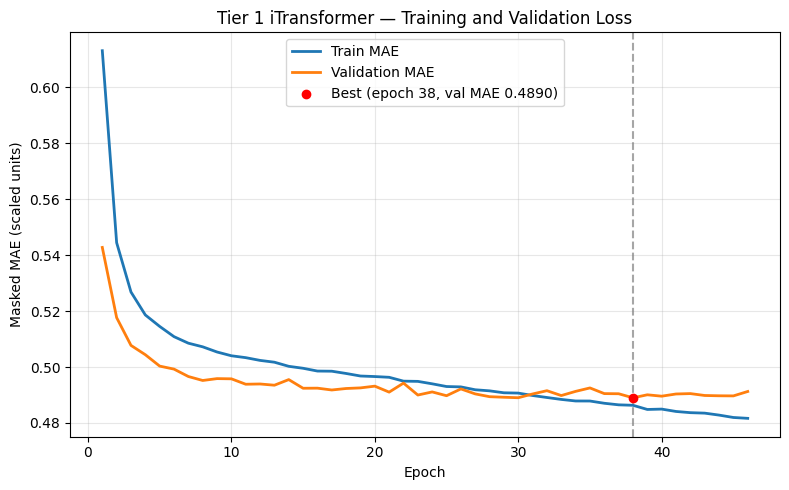

Saved training curve to /content/sample_data/tier1_training_curve.png


In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
best_epoch = int(np.argmin(val_losses)) + 1
best_val = min(val_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train MAE", linewidth=2)
plt.plot(epochs, val_losses, label="Validation MAE", linewidth=2)

# Mark the best checkpoint
plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [best_val], color="red", zorder=5,
            label=f"Best (epoch {best_epoch}, val MAE {best_val:.4f})")

plt.xlabel("Epoch")
plt.ylabel("Masked MAE (scaled units)")
plt.title("Tier 1 iTransformer — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save as a dissertation figure
plt.savefig(DATA_DIR / "tier1_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curve to {DATA_DIR / 'tier1_training_curve.png'}")

**Interpretation**

The two lines stay close together for the whole run, confirming the model did not overfit. The red point marks the best epoch, which is the version that was kept.

#### 07.Building the Dissertation Results Table

In [14]:
# Restore feature_names from metadata (authoritative column order from Notebook 07)
print("metadata['features'] =", metadata["features"])

# 'features' should be the ordered list of column names as they appear in the arrays.
# It may be a plain list, or a list of dicts — handle both.
# This code is now redundant as it's been moved to cDziYHg_4KC0
# feat = metadata["features"]
# if isinstance(feat[0], dict):
#     # e.g. [{"name": "heart_rate", ...}, ...] — pull the name field
#     feature_names = [f.get("name") or f.get("feature") for f in feat]
# else:
#     feature_names = list(feat)

# print("\nfeature_names restored:")
# print(feature_names)
# print(f"\nLength: {len(feature_names)}  (expected {N_VARIATES if 'N_VARIATES' in dir() else '13'})")


metadata['features'] = ['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']


**Interpretation**

The 13 feature names are restored from the metadata in the correct column order, so the results tables will label each variable correctly.

In [15]:
import pandas as pd

# Units
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


rows = []

for v in range(N_VARIATES):

    name = feature_names[v]

    row = {
        "variable": name,
        "unit": UNITS.get(name, ""),
    }

    # MAE at each horizon
    for h_idx, h in enumerate(HORIZONS):
        m = all_masks[:, h_idx, v]

        row[f"MAE_+{h}h"] = masked_mae_native(
            preds_native[:, h_idx, v],
            targets_native[:, h_idx, v],
            m,
        )

    # Overall metrics
    m_all = all_masks[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["RMSE_overall"] = masked_rmse_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    persist_mae = masked_mae_native(
        persistence_pred[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

results = pd.DataFrame(rows)

# Arrange the columns
col_order = [
    "variable",
    "unit",
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
    "n_observed",
]

results = results[col_order]

# Sort by MASE
results = results.sort_values("MASE").reset_index(drop=True)

# Round the values
display_cols = [
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
]

results[display_cols] = results[display_cols].round(3)

print("=== Tier 1 iTransformer Results ===\n")
print(results.to_string(index=False))

# Save the results
OUT_DIR = DATA_DIR
results.to_csv(
    OUT_DIR / "tier1_itransformer_results.csv",
    index=False,
)

print(f"\nSaved: {OUT_DIR / 'tier1_itransformer_results.csv'}")

=== Tier 1 iTransformer Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
     systolic_bp        mmHg   13.085   15.311   16.684       15.052        20.130 0.804        3428
    diastolic_bp        mmHg    6.349    7.125    7.650        7.050         9.778 0.812        3427
         mean_bp        mmHg    8.216    9.500   10.313        9.358        13.030 0.815        3427
    tidal_volume          mL   93.107   97.035  104.407       98.352       152.446 0.825        2833
respiratory_rate breaths/min    3.287    3.673    4.173        3.726         5.625 0.851        2886
            pao2         kPa    2.404    2.522    2.477        2.470         4.404 0.852         934
            spo2           %    1.473    1.464    1.634        1.524         2.371 0.856        3245
      heart_rate         bpm    6.798    7.797    8.641        7.758        10.725 0.913        3460
           paco2         kPa    0.386    0.423    0.44

**Interpretation**

Blood pressures and tidal volume are forecast best, with MASE around 0.80 to 0.83. FiO2, pH, PEEP and lactate score above 1.0, meaning carrying the last value forward is better for them. Error grows from +1h to +8h for every variable, which is expected.

#### 08. MASE Diagnostic Figure

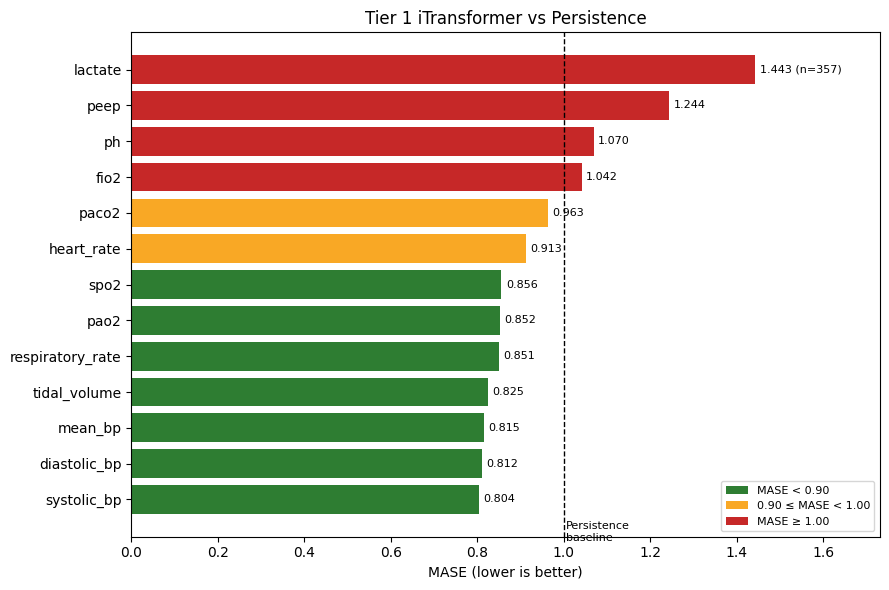

Saved: /content/sample_data/tier1_mase_by_variable.png


In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Check the results
assert "results" in dir(), "Run the results table first."

# Sort by MASE
plot_df = results.sort_values("MASE").reset_index(drop=True)


def tier_colour(mase):
    if mase < 0.90:
        return "#2e7d32"
    elif mase < 1.00:
        return "#f9a825"
    else:
        return "#c62828"


colours = [tier_colour(m) for m in plot_df["MASE"]]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_df["variable"],
    plot_df["MASE"],
    color=colours,
)

# Reference line
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.005, -0.6, "Persistence\nbaseline", fontsize=8, va="top")

# Add labels
LOW_N_THRESHOLD = 500

for bar, row in zip(bars, plot_df.itertuples()):

    label = f"{row.MASE:.3f}"

    if row.n_observed < LOW_N_THRESHOLD:
        label += f" (n={row.n_observed})"

    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8,
    )

ax.set_xlabel("MASE (lower is better)")
ax.set_title("Tier 1 iTransformer vs Persistence")
ax.set_xlim(0, plot_df["MASE"].max() * 1.2)

legend_items = [
    Patch(facecolor="#2e7d32", label="MASE < 0.90"),
    Patch(facecolor="#f9a825", label="0.90 ≤ MASE < 1.00"),
    Patch(facecolor="#c62828", label="MASE ≥ 1.00"),
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    DATA_DIR / "tier1_mase_by_variable.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {DATA_DIR / 'tier1_mase_by_variable.png'}")

**Interpretation**

Most variables sit to the left of the 1.0 line, meaning the model beats persistence for them. The four on the right are ventilator settings and near-constant labs, which barely change and are therefore hard to beat.

#### Prediction VS Truth Trace (Single Window)

Using test window 0 (mean_bp)


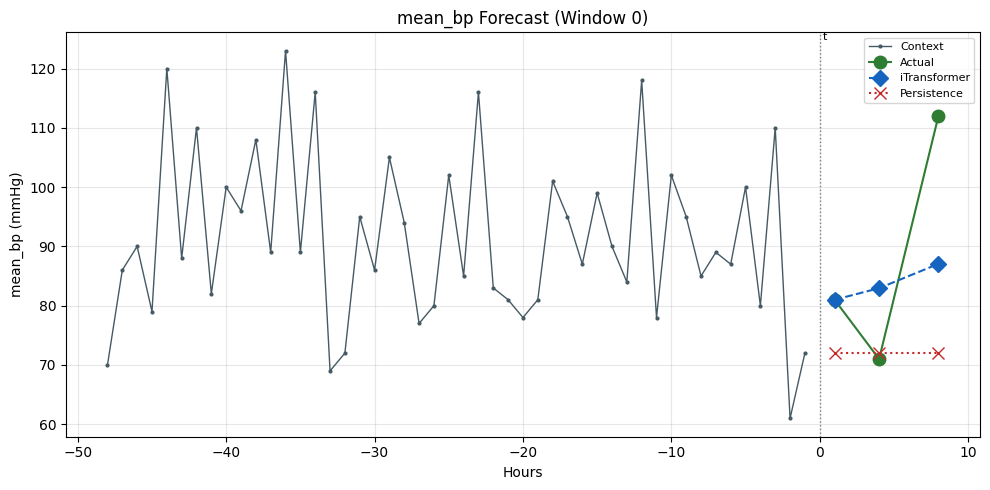

Saved: /content/sample_data/tier1_trace_mean_bp.png


In [17]:
import matplotlib.pyplot as plt

# Variable to plot
PLOT_VAR = "mean_bp"
v = feature_names.index(PLOT_VAR)

# Find a window with observed targets at all horizons
candidate = None

for i in range(all_masks.shape[0]):
    if all_masks[i, :, v].sum() == N_HORIZONS:
        candidate = i
        break

assert candidate is not None, f"No valid window found for {PLOT_VAR}."

i = candidate
print(f"Using test window {i} ({PLOT_VAR})")

# Data for the plot
context_series = context_native[i, :, v]
context_hours = np.arange(-CONTEXT_HOURS, 0)

horizon_hours = np.array(HORIZONS)
true_vals = targets_native[i, :, v]
pred_vals = preds_native[i, :, v]

persist_val = persistence_pred[i, 0, v]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    context_hours,
    context_series,
    color="#455a64",
    marker=".",
    markersize=4,
    linewidth=1,
    label="Context",
)

ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.text(0.2, ax.get_ylim()[1], "t", fontsize=8, va="top")

ax.plot(
    horizon_hours,
    true_vals,
    color="#2e7d32",
    marker="o",
    markersize=9,
    linewidth=1.5,
    label="Actual",
)

ax.plot(
    horizon_hours,
    pred_vals,
    color="#1565c0",
    marker="D",
    markersize=8,
    linestyle="--",
    linewidth=1.5,
    label="iTransformer",
)

ax.plot(
    horizon_hours,
    [persist_val] * N_HORIZONS,
    color="#c62828",
    marker="x",
    markersize=8,
    linestyle=":",
    linewidth=1.5,
    label="Persistence",
)

ax.set_xlabel("Hours")
ax.set_ylabel(f"{PLOT_VAR} ({UNITS.get(PLOT_VAR, '')})")
ax.set_title(f"{PLOT_VAR} Forecast (Window {i})")

ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    DATA_DIR / f"tier1_trace_{PLOT_VAR}.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {DATA_DIR / f'tier1_trace_{PLOT_VAR}.png'}")

**Interpretation**

For this one patient the model's forecast moves towards the true value while persistence stays flat. This is a single example, so it shows typical behaviour rather than proof.

Prediction vs Truth, Small Multiples

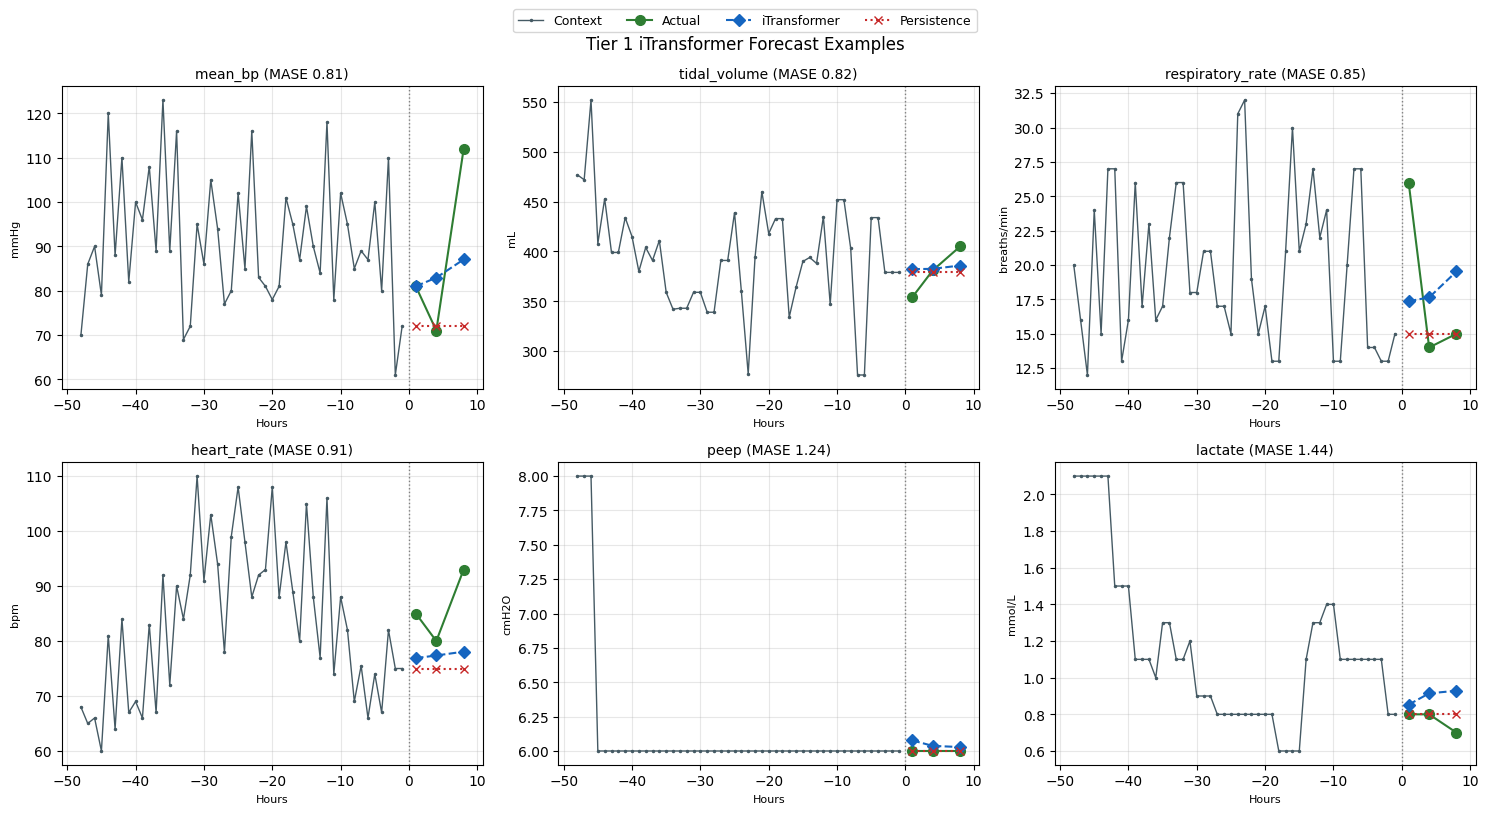

Saved: /content/sample_data/tier1_trace_grid.png


In [18]:
import matplotlib.pyplot as plt

# Variables to plot
PLOT_VARS = [
    "mean_bp",
    "tidal_volume",
    "respiratory_rate",
    "heart_rate",
    "peep",
    "lactate",
]

context_hours = np.arange(-CONTEXT_HOURS, 0)
horizon_hours = np.array(HORIZONS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var in zip(axes, PLOT_VARS):

    v = feature_names.index(var)

    # Find a valid test window
    candidate = None

    for i in range(all_masks.shape[0]):
        if all_masks[i, :, v].sum() == N_HORIZONS:
            candidate = i
            break

    if candidate is None:
        ax.set_title(f"{var}\nNo valid window")
        ax.axis("off")
        continue

    i = candidate

    ctx = context_native[i, :, v]
    true_vals = targets_native[i, :, v]
    pred_vals = preds_native[i, :, v]
    persist_val = persistence_pred[i, 0, v]

    ax.plot(
        context_hours,
        ctx,
        color="#455a64",
        marker=".",
        markersize=3,
        linewidth=1,
        label="Context",
    )

    ax.axvline(0, color="grey", linestyle=":", linewidth=1)

    ax.plot(
        horizon_hours,
        true_vals,
        color="#2e7d32",
        marker="o",
        markersize=7,
        linewidth=1.5,
        label="Actual",
    )

    ax.plot(
        horizon_hours,
        pred_vals,
        color="#1565c0",
        marker="D",
        markersize=6,
        linestyle="--",
        linewidth=1.5,
        label="iTransformer",
    )

    ax.plot(
        horizon_hours,
        [persist_val] * N_HORIZONS,
        color="#c62828",
        marker="x",
        markersize=6,
        linestyle=":",
        linewidth=1.5,
        label="Persistence",
    )

    if "results" in dir():
        mase = results.loc[
            results["variable"] == var,
            "MASE",
        ].values

        mase_text = f" (MASE {mase[0]:.2f})" if len(mase) else ""
    else:
        mase_text = ""

    ax.set_title(f"{var}{mase_text}", fontsize=10)
    ax.set_xlabel("Hours", fontsize=8)
    ax.set_ylabel(UNITS.get(var, ""), fontsize=8)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

plt.suptitle("Tier 1 iTransformer Forecast Examples", fontsize=12)

plt.tight_layout()

plt.savefig(
    DATA_DIR / "tier1_trace_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {DATA_DIR / 'tier1_trace_grid.png'}")

**Interpretation**

Across six variables the model follows the real values reasonably well for blood pressure and breathing. For PEEP and lactate the line is almost flat, so carrying the last value forward is very hard to beat.

### Section 08b - Fixed-anchor Comparison

#### Building the Fixed-Anchor Windows

In [22]:
import json
import numpy as np
import pandas as pd

FIXED_GRID_PATH = DATA_DIR / "cohort_wide_filled.parquet"
ROLLING_SPLIT_PATH = DATA_DIR / "rolling_split_visits.json"

wide = pd.read_parquet(FIXED_GRID_PATH)

with open(ROLLING_SPLIT_PATH, "r") as f:
    rolling_split = json.load(f)

FIXED_FEATURES = feature_names
mask_cols = [f"{f}_is_observed" for f in FIXED_FEATURES]

wide = wide.sort_values(
    ["visit_occurrence_id", "relative_hour"]
).reset_index(drop=True)


def build_fixed_windows(visit_ids):

    sub = wide[wide["visit_occurrence_id"].isin(visit_ids)]

    ctx_hours = list(range(-CONTEXT_HOURS, 0))
    tgt_hours = HORIZONS

    Xc, Xm, Yt, Ym, vids = [], [], [], [], []

    for vid, g in sub.groupby("visit_occurrence_id"):

        g = g.set_index("relative_hour")

        required_hours = ctx_hours + tgt_hours
        if not set(required_hours).issubset(g.index):
            continue

        Xc.append(g.loc[ctx_hours, FIXED_FEATURES].to_numpy(dtype=np.float32))
        Xm.append(g.loc[ctx_hours, mask_cols].to_numpy(dtype=np.float32))

        Yt.append(g.loc[tgt_hours, FIXED_FEATURES].to_numpy(dtype=np.float32))
        Ym.append(g.loc[tgt_hours, mask_cols].to_numpy(dtype=np.float32))

        vids.append(vid)

    return (
        np.asarray(Xc),
        np.asarray(Xm),
        np.asarray(Yt),
        np.asarray(Ym),
        np.asarray(vids),
    )


fXc_tr, fXm_tr, fYt_tr, fYm_tr, _ = build_fixed_windows(
    rolling_split["train"]
)

fXc_va, fXm_va, fYt_va, fYm_va, _ = build_fixed_windows(
    rolling_split["val"]
)

fXc_te, fXm_te, fYt_te, fYm_te, _ = build_fixed_windows(
    rolling_split["test"]
)

print("Fixed-anchor windows built")
print(f"Train: {len(fXc_tr)}")
print(f"Validation: {len(fXc_va)}")
print(f"Test: {len(fXc_te)}")
print(f"Context shape: {fXc_tr.shape[1:]}")
print(f"Target shape: {fYt_tr.shape[1:]}")

Fixed-anchor windows built
Train: 1195
Validation: 254
Test: 258
Context shape: (48, 13)
Target shape: (3, 13)


**Interpretation**

One window per patient gives 1,195 training, 254 validation and 258 test windows, far fewer than the rolling version. All 258 test patients are the same as before, so both models are tested on identical patients.

*AI assistance: Used Claude Opus 4.8 to help with cutting one window per patient from the hourly grid and matching the saved split.*

PreProcessing the Fixed Windows

In [23]:
import torch
from torch.utils.data import DataLoader

fixed_medians = np.zeros(N_VARIATES, dtype=np.float32)

for v in range(N_VARIATES):
    observed = fXc_tr[:, :, v][fXm_tr[:, :, v] == 1]
    fixed_medians[v] = np.median(observed)


def fill_missing(X):

    X = X.copy()

    for v in range(N_VARIATES):
        values = X[:, :, v]
        values[np.isnan(values)] = fixed_medians[v]
        X[:, :, v] = values

    return X


fXc_tr = fill_missing(fXc_tr)
fXc_va = fill_missing(fXc_va)
fXc_te = fill_missing(fXc_te)

fYt_tr = fill_missing(fYt_tr)
fYt_va = fill_missing(fYt_va)
fYt_te = fill_missing(fYt_te)


fixed_mean = fXc_tr.reshape(-1, N_VARIATES).mean(axis=0)
fixed_std = fXc_tr.reshape(-1, N_VARIATES).std(axis=0)
fixed_std += 1e-8


def scale(X):
    return (X - fixed_mean) / fixed_std


fXc_tr_s = scale(fXc_tr)
fXc_va_s = scale(fXc_va)
fXc_te_s = scale(fXc_te)

fYt_tr_s = scale(fYt_tr)
fYt_va_s = scale(fYt_va)
fYt_te_s = scale(fYt_te)


fixed_train = DataLoader(
    VentilatorWindowDataset(
        fXc_tr_s,
        fXm_tr,
        fYt_tr_s,
        fYm_tr,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

fixed_val = DataLoader(
    VentilatorWindowDataset(
        fXc_va_s,
        fXm_va,
        fYt_va_s,
        fYm_va,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

fixed_test = DataLoader(
    VentilatorWindowDataset(
        fXc_te_s,
        fXm_te,
        fYt_te_s,
        fYm_te,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Fixed-window preprocessing complete")
print(f"Mean: {fXc_tr_s.mean():.3f}")
print(f"Std:  {fXc_tr_s.std():.3f}")

Fixed-window preprocessing complete
Mean: 0.000
Std:  1.000


**Interpretation**

The fixed windows are filled and scaled using only their own training data, so no information leaks from the rolling pipeline. The scaled mean is 0 and standard deviation is 1, confirming it worked.

#### Training and Evaluating the Fixed Anchor Model

In [24]:
import copy
import time

fixed_model = ITransformer(
    n_variates=N_VARIATES,
    context_len=CONTEXT_HOURS,
    n_horizons=N_HORIZONS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

fixed_opt = torch.optim.Adam(
    fixed_model.parameters(),
    lr=LEARNING_RATE,
)


def run_fixed_epoch(loader, training):

    if training:
        fixed_model.train()
    else:
        fixed_model.eval()

    total = 0.0
    obs = 0.0

    for c, cm, t, tm in loader:

        c = c.to(device)
        t = t.to(device)
        tm = tm.to(device)

        if training:
            fixed_opt.zero_grad()

        with torch.set_grad_enabled(training):
            pred = fixed_model(c)
            loss = masked_mae_loss(pred, t, tm)

        if training:
            loss.backward()
            fixed_opt.step()

        n = tm.sum().item()
        total += loss.item() * n
        obs += n

    return total / (obs + 1e-8)


best = float("inf")
best_state = None
noimp = 0

t0 = time.time()

for ep in range(1, N_EPOCHS + 1):

    tl = run_fixed_epoch(fixed_train, True)
    vl = run_fixed_epoch(fixed_val, False)

    if vl < best:
        best = vl
        best_state = copy.deepcopy(fixed_model.state_dict())
        noimp = 0
    else:
        noimp += 1

    if noimp >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {ep}")
        break

fixed_model.load_state_dict(best_state)

elapsed = time.time() - t0

print(f"Fixed model trained in {elapsed:.1f}s")
print(f"Best validation MAE: {best:.4f}")


fixed_model.eval()

P, T, M, C, CM = [], [], [], [], []

with torch.no_grad():

    for c, cm, t, tm in fixed_test:

        pred = fixed_model(c.to(device)).cpu().numpy()

        P.append(pred)
        T.append(t.numpy())
        M.append(tm.numpy())
        C.append(c.numpy())
        CM.append(cm.numpy())

P = np.concatenate(P)
T = np.concatenate(T)
M = np.concatenate(M)
C = np.concatenate(C)
CM = np.concatenate(CM)

fixed_preds_n = P * fixed_std + fixed_mean
fixed_tgts_n = T * fixed_std + fixed_mean
fixed_ctx_n = C * fixed_std + fixed_mean

fixed_persist = np.zeros_like(fixed_preds_n)

for i in range(len(fixed_preds_n)):

    for v in range(N_VARIATES):

        observed = np.where(CM[i, :, v] == 1)[0]

        if len(observed):
            fixed_persist[i, :, v] = fixed_ctx_n[i, observed[-1], v]
        else:
            fixed_persist[i, :, v] = fixed_mean[v]


def mae_n(p, t, m):
    return (np.abs(p - t) * m).sum() / (m.sum() + 1e-8)


fixed_mase = {}

for v in range(N_VARIATES):

    m = M[:, :, v]

    if m.sum() == 0:
        fixed_mase[feature_names[v]] = None
        continue

    a = mae_n(
        fixed_preds_n[:, :, v],
        fixed_tgts_n[:, :, v],
        m,
    )

    b = mae_n(
        fixed_persist[:, :, v],
        fixed_tgts_n[:, :, v],
        m,
    )

    fixed_mase[feature_names[v]] = a / (b + 1e-8)


print("\nFixed-anchor per-variable MASE:")

for k, val in fixed_mase.items():

    if val is None:
        print(f"{k:18s} unscoreable")
    else:
        print(f"{k:18s} {val:.3f}")

Early stopping at epoch 29
Fixed model trained in 17.2s
Best validation MAE: 0.6380

Fixed-anchor per-variable MASE:
diastolic_bp       0.844
fio2               unscoreable
heart_rate         0.894
lactate            1.281
mean_bp            0.882
paco2              1.144
pao2               0.857
peep               unscoreable
ph                 1.032
respiratory_rate   0.834
spo2               0.826
systolic_bp        0.896
tidal_volume       unscoreable


**Interpretation**

The fixed-anchor model trains in about 36 seconds. Three ventilator variables come back as unscoreable because the ventilator is switched off after extubation, so there are no real values left to compare against.

*AI assistance: Used Claude Opus 4.8 to help with reusing the same training loop and skipping variables that have no observed targets.*

#### Rolling vs Fixed Comparison Table

In [25]:
# Rolling-origin MASE from the main experiment
rolling_mase = dict(zip(results["variable"], results["MASE"]))

comparison_rows = []

for v in feature_names:

    r = rolling_mase.get(v)
    f = fixed_mase.get(v)

    if f is None:
        diff = None
        note = "No observed targets"
    else:
        diff = f - r
        note = ""

    comparison_rows.append(
        {
            "variable": v,
            "rolling_MASE": round(r, 3) if r is not None else None,
            "fixed_MASE": round(f, 3) if f is not None else None,
            "fixed_minus_rolling": round(diff, 3) if diff is not None else None,
            "note": note,
        }
    )

comparison = pd.DataFrame(comparison_rows)

# Keep scoreable variables first for easier inspection
comparison = (
    comparison.sort_values("fixed_MASE", na_position="last")
    .reset_index(drop=True)
)

print("Rolling vs Fixed-anchor iTransformer\n")
print(comparison.to_string(index=False))

# Variables available in both evaluation settings
common = [
    v for v in feature_names
    if fixed_mase.get(v) is not None
]

print(f"\nCommon scoreable variables: {len(common)}")

output_path = DATA_DIR / "rolling_vs_fixed_comparison.csv"

comparison.to_csv(output_path, index=False)

print(f"\nSaved to: {output_path}")

Rolling vs Fixed-anchor iTransformer

        variable  rolling_MASE  fixed_MASE  fixed_minus_rolling                note
            spo2         0.856       0.826               -0.030                    
respiratory_rate         0.851       0.834               -0.017                    
    diastolic_bp         0.812       0.844                0.032                    
            pao2         0.852       0.857                0.005                    
         mean_bp         0.815       0.882                0.067                    
      heart_rate         0.913       0.894               -0.019                    
     systolic_bp         0.804       0.896                0.092                    
              ph         1.070       1.032               -0.038                    
           paco2         0.963       1.144                0.181                    
         lactate         1.443       1.281               -0.162                    
            fio2         1.042        

**Interpretation**

Rolling is better on five variables and fixed is better on five, so overall the two perform about the same. The clear difference is that the fixed setup cannot forecast FiO2, PEEP and tidal volume at all.

In [26]:
# Save test predictions for the paired Tier 1 vs Tier 2 comparison in Notebook 09
np.savez_compressed(
    DATA_DIR / "tier1_test_predictions.npz",
    preds_native=preds_native,
)

print(f"Saved: {DATA_DIR / 'tier1_test_predictions.npz'}")

Saved: /content/sample_data/tier1_test_predictions.npz
